In [1]:
import networkx as nx
import numpy as np
import json
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

Question 1

In [2]:
G = nx.DiGraph()
with open('../data/polblogs_nodes_class.tsv','r') as fp:
    for line in fp:
        node_id, node_label, node_political = line.strip().split('\t')
        political_orientation = 'liberal' if node_political == '0' else 'conservative'
        G.add_node(node_id, website=node_label, political_orientation=political_orientation)

In [3]:
with open('../data/polblogs_edges_class.tsv','r') as fp:
    for line in fp:
        source_node_id, target_node_id = line.strip().split('\t')
        G.add_edge(source_node_id, target_node_id)

(a)

In [4]:
nx.write_edgelist(G,"../data/polblogs.edgelist")

In [5]:
G_edge = nx.read_edgelist("../data/polblogs.edgelist")

In [6]:
nx.write_graphml(G,"../data/polblogs.graphml")

In [7]:
G_graphml =nx.read_graphml("../data/polblogs.graphml")

In [8]:
d = nx.node_link_data(G)

In [9]:
with open('../data/polblogs.json', 'w') as fp:
    json.dump(d, fp)

In [10]:
with open('../data/polblogs.json', 'r') as fp:
    data_back = json.load(fp)

In [11]:
G_json = nx.node_link_graph(data_back)

In [12]:
with open('../data/polblogs.pkl', 'wb') as fp:
    pickle.dump(G, fp)

In [13]:
fp

<_io.BufferedWriter name='../data/polblogs.pkl'>

In [14]:
with open('../data/polblogs.pkl', 'rb') as fp:
    G_pickle = pickle.load(fp)

In [15]:
d=nx.to_numpy_array(G)

In [16]:
np.save('../data/polblogs.npy',d)

In [17]:
d =np.load('../data/polblogs.npy')
G_matrix =nx.from_numpy_array(d)

In [18]:
graphs = {
    'original G': G,
    'edge list': G_edge,
    'GraphML': G_graphml,
    'JSON': G_json,
    'pickle': G_pickle,
    'dense adjacency matrix': G_matrix
}

In [19]:
files = {
    'original G': None,
    'edge list': '../data/polblogs.edgelist',
    'GraphML': '../data/polblogs.graphml',
    'JSON': '../data/polblogs.json',
    'pickle': '../data/polblogs.pkl',
    'dense adjacency matrix': '../data/polblogs.npy'
}

In [20]:
results = []

for format_name, G_back in graphs.items():

    attrs_present = all(
        'website' in data and 'political_orientation' in data
        for _, data in G_back.nodes(data=True)
    )

    file_size = (
        os.path.getsize(files[format_name])
        if files[format_name] is not None
        else None
    )

    results.append({
        'format': format_name,
        'file_size': file_size,
        'nodes': G_back.number_of_nodes(),
        'edges': G_back.number_of_edges(),
        'directed': G_back.is_directed(),
        'node_attributes': attrs_present,
        'graphs_equal': nx.utils.graphs_equal(G, G_back)
    })

In [21]:
df = pd.DataFrame(results)
df

,format,file_size,nodes,edges,directed,node_attributes,graphs_equal
0,original G,NaN,1490,19025,True,True,True
1,edge list,218705.0,1224,16718,False,False,False
2,GraphML,814642.0,1490,19025,True,True,False
3,JSON,829963.0,1490,19025,True,True,True
4,pickle,459290.0,1490,19025,True,True,True
5,dense adjacency matrix,17760928.0,1490,16718,False,False,False


(b)

1. For the edgelist format, several nodes, edges, and node attributes are missing, and the direction is different.
2. For the GraphML format, seems nothing is missing and different, but it's not equal to the original G.
3. For the JSON and pickle formats, nothing is missing or different.
4. For the dense adjacency matrix, several edges and node attributes are missing, and the direction is now different.

In [22]:
for name, graph in graphs.items():
    print(name)
    print("nodes:", graph.number_of_nodes())
    print("edges:", graph.number_of_edges())
    print("directed:", graph.is_directed())
    print("first 5 node labels:", list(graph.nodes())[:5])
    print("node label type:", type(list(graph.nodes())[0]))
    print("first node attributes:", graph.nodes[list(graph.nodes())[0]])
    print()

original G
nodes: 1490
edges: 19025
directed: True
first 5 node labels: ['0', '1', '2', '3', '4']
node label type: <class 'str'>
first node attributes: {'website': '100monkeystyping.com', 'political_orientation': 'liberal'}

edge list
nodes: 1224
edges: 16718
directed: False
first 5 node labels: ['0', '22', '54', '84', '154']
node label type: <class 'str'>
first node attributes: {}

GraphML
nodes: 1490
edges: 19025
directed: True
first 5 node labels: ['0', '1', '2', '3', '4']
node label type: <class 'str'>
first node attributes: {'website': '100monkeystyping.com', 'political_orientation': 'liberal'}

JSON
nodes: 1490
edges: 19025
directed: True
first 5 node labels: ['0', '1', '2', '3', '4']
node label type: <class 'str'>
first node attributes: {'website': '100monkeystyping.com', 'political_orientation': 'liberal'}

pickle
nodes: 1490
edges: 19025
directed: True
first 5 node labels: ['0', '1', '2', '3', '4']
node label type: <class 'str'>
first node attributes: {'website': '100monkeysty

In [23]:
# Inspect the saved edge list.
with open("../data/polblogs.edgelist") as fp:
    for _ in range(5):
        print(fp.readline().rstrip())

# Check whether the missing nodes are precisely the isolated nodes.
missing_nodes = set(G) - set(G_edge)
print(len(missing_nodes))
print(missing_nodes == set(nx.isolates(G)))

# Inspect the saved matrix.
A = np.load("../data/polblogs.npy")
print(A.shape, A.dtype)
print(A[:5, :5])
print("Symmetric:", np.array_equal(A, A.T))

# Inspect edge attributes created by matrix conversion.
print(next(iter(G_matrix.edges(data=True))))

0 22 {}
0 54 {}
0 84 {}
0 154 {}
0 322 {}
266
True
(1490, 1490) float64
[[0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
Symmetric: False
(0, 22, {'weight': 1.0})


In [24]:
A = np.load("../data/polblogs.npy")

print("Array shape:", A.shape)
print("Array data type:", A.dtype)
print("Top-left 5×5 block:")
print(A[:5, :5])

print("Is the matrix symmetric?", np.array_equal(A, A.T))
print("Number of nonzero entries:", np.count_nonzero(A))

# Check whether the saved array matches the original graph's adjacency matrix
print("Saved array matches the original adjacency matrix:",
      np.array_equal(A, nx.to_numpy_array(G)))

print("First edge in the graph reconstructed from the matrix:",
      next(iter(G_matrix.edges(data=True))))

Array shape: (1490, 1490)
Array data type: float64
Top-left 5×5 block:
[[0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
Is the matrix symmetric? False
Number of nonzero entries: 19025
Saved array matches the original adjacency matrix: True
First edge in the graph reconstructed from the matrix: (0, 22, {'weight': 1.0})


In [25]:
H_default = nx.from_numpy_array(A)
H_directed = nx.from_numpy_array(A, create_using=nx.DiGraph())

print("Default:", H_default.is_directed(), H_default.number_of_edges())
print("Directed:", H_directed.is_directed(), H_directed.number_of_edges())

Default: False 16718
Directed: True 19025


In [26]:
# Count reciprocal pairs, excluding self-loops.
# Each pair is encountered twice, so divide by 2.
reciprocal_pairs = sum(
    1 for u, v in G.edges()
    if u != v and G.has_edge(v, u)
) // 2

edge_difference = G.number_of_edges() - H_default.number_of_edges()

print("Reciprocal pairs:", reciprocal_pairs)
print("Edge-count difference:", edge_difference)
print("Counts match:", reciprocal_pairs == edge_difference)

Reciprocal pairs: 2307
Edge-count difference: 2307
Counts match: True


For the edge list, isolated nodes and node attributes were omitted when the file was saved. However, the ordered edge endpoints are still present in the file. The loss of direction and the reduced edge count occur during loading, because the default reader creates an undirected graph and merges reciprocal edges.

For the dense adjacency matrix, the original node labels and node attributes were not stored when the graph was converted to an array. However, the saved array still contains the directed connections. The loss of direction and the reduced edge count occur during loading, because `nx.from_numpy_array` creates an undirected graph by default. It also assigns integer node labels based on the array indices.

(c)

In [27]:
# Load the edge list as a directed graph.
G_edge_fixed = nx.read_edgelist(
    "../data/polblogs.edgelist",
    create_using=nx.DiGraph()
)

# Verify the reconstructed graph.
print("Nodes:", G_edge_fixed.number_of_nodes())
print("Edges:", G_edge_fixed.number_of_edges())
print("Directed:", G_edge_fixed.is_directed())

print("Node attributes present:", all(
    "website" in data and "political_orientation" in data
    for _, data in G_edge_fixed.nodes(data=True)
))

print("Node labels match:",
      set(G_edge_fixed.nodes()) == set(G.nodes()))

print("Graphs equal:",
      nx.utils.graphs_equal(G, G_edge_fixed))

Nodes: 1224
Edges: 19025
Directed: True
Node attributes present: False
Node labels match: False
Graphs equal: False


In [28]:
G_matrix_fixed = nx.from_numpy_array(
    d,
    create_using=nx.DiGraph(),
    edge_attr=None,
    nodelist=list(G.nodes())
)

print("Nodes:", G_matrix_fixed.number_of_nodes())
print("Edges:", G_matrix_fixed.number_of_edges())
print("Directed:", G_matrix_fixed.is_directed())

print("Node attributes present:", all(
    "website" in data and "political_orientation" in data
    for _, data in G_matrix_fixed.nodes(data=True)
))

print("Node labels match:",
      set(G_matrix_fixed.nodes()) == set(G.nodes()))

print("Graphs equal:",
      nx.utils.graphs_equal(G, G_matrix_fixed))

Nodes: 1490
Edges: 19025
Directed: True
Node attributes present: False
Node labels match: True
Graphs equal: False


For the edge list, I used `create_using=nx.DiGraph()` to restore direction and all 19,025 edges. However, the 266 isolated nodes and node attributes cannot be recovered through loading arguments because they were not saved in the file.

For the dense adjacency matrix, I used `create_using=nx.DiGraph()` to restore direction and the original edge count, and `edge_attr=None` to avoid adding weight attributes. I also used `nodelist=list(G.nodes())` to restore the original string labels, supplying the same node order used when saving the matrix. These labels cannot be recovered from the array alone.

Node attributes remain missing because the matrix did not store them. Therefore, `graphs_equal` remains `False` for both reconstructed graphs.

(d)

In [33]:
print(G.graph)
print(G_graphml.graph)

print("Adjacency equal:", G.adj == G_graphml.adj)
print("Nodes equal:", G.nodes == G_graphml.nodes)
print("Graph attributes equal:", G.graph == G_graphml.graph)
print("Node attributes equal:",dict(G.nodes(data=True)) == dict(G_graphml.nodes(data=True)))

{}
{'node_default': {}, 'edge_default': {}}
Adjacency equal: True
Nodes equal: True
Graph attributes equal: False
Node attributes equal: True


GraphML returns False for graphs_equal() because the graph-level attributes are different. The original G.graph is empty, but after loading the GraphML file, G_graphml.graph contains node_default and edge_default as empty dictionaries. graphs_equal() also checks graph-level attributes, so it returns False.

I don't think this difference matters here because the nodes, edges, direction, and node attributes are all the same. The extra graph attributes are only empty default metadata.

(e)

In [36]:
H = nx.path_graph(5)

nx.write_edgelist(H, "../data/path.edgelist")
H_edge = nx.read_edgelist("../data/path.edgelist")

nx.write_graphml(H, "../data/path.graphml")
H_graphml = nx.read_graphml("../data/path.graphml")

print("Original:", list(H.nodes()), type(next(iter(H.nodes()))))
print("Edge list:", list(H_edge.nodes()), type(next(iter(H_edge.nodes()))))
print("GraphML:", list(H_graphml.nodes()), type(next(iter(H_graphml.nodes()))))

Original: [0, 1, 2, 3, 4] <class 'int'>
Edge list: ['0', '1', '2', '3', '4'] <class 'str'>
GraphML: ['0', '1', '2', '3', '4'] <class 'str'>


In [37]:
H_edge_int = nx.read_edgelist(
    "../data/path.edgelist",
    nodetype=int
)

H_graphml_int = nx.read_graphml(
    "../data/path.graphml",
    node_type=int
)

print(type(next(iter(H_edge_int.nodes()))))
print(type(next(iter(H_graphml_int.nodes()))))

<class 'int'>
<class 'int'>


With the default loading arguments, both the edge-list and GraphML formats return the node labels as strings, even though the original graph used integer labels. For the edge list, nodetype=int converts the labels back to integers. For GraphML, the corresponding argument is node_type=int.

However, someone receiving only these files would not necessarily know that the node labels were originally integers. They would need documentation or other metadata describing the intended node-label type.

(f)

The dense adjacency matrix is the largest file (17,760,928 bytes), while the edge list is the smallest (218,705 bytes).

In [40]:
print("Original number of nodes:", G.number_of_nodes())

print("\nEdge list:")
print("Nodes after loading:", G_edge.number_of_nodes())
print("Edges after loading:", G_edge.number_of_edges())
print("Missing nodes:", G.number_of_nodes() - G_edge.number_of_nodes())

print("\nDense adjacency matrix:")
print("Matrix shape:", d.shape)
print("Total matrix entries:", d.size)
print("Nonzero entries:", np.count_nonzero(d))
print("Zero entries:", d.size - np.count_nonzero(d))

Original number of nodes: 1490

Edge list:
Nodes after loading: 1224
Edges after loading: 16718
Missing nodes: 266

Dense adjacency matrix:
Matrix shape: (1490, 1490)
Total matrix entries: 2220100
Nonzero entries: 19025
Zero entries: 2201075


The dense adjacency matrix is the largest file, while the edge list is the smallest. The dense matrix has shape (1490, 1490), so it stores 2,220,100 entries, including 2,201,075 zeros for node pairs without an edge. It also keeps positions for all 1,490 nodes, including isolated nodes. In contrast, the edge list only stores existing edges, so the 266 isolated nodes do not appear in the graph loaded from the edge-list file.

In [41]:
n_current = G.number_of_nodes()
n_large = 10**6

edge_size = os.path.getsize("../data/polblogs.edgelist")
matrix_size = os.path.getsize("../data/polblogs.npy")

edge_estimate = edge_size * (n_large / n_current)
matrix_estimate = matrix_size * (n_large / n_current) ** 2

print("Estimated edge list size:", edge_estimate / 1e6, "MB")
print("Estimated dense matrix size:", matrix_estimate / 1e12, "TB")

Estimated edge list size: 146.78187919463087 MB
Estimated dense matrix size: 8.000057655060582 TB


Since the average number of edges per node stays the same, the number of edges grows approximately linearly with the number of nodes. Therefore, I scale the edge-list file size by \(10^6/1490\), giving an estimated size of about 147 MB.  
A dense adjacency matrix has \(n^2\) entries, so I scale its current file size by \((10^6/1490)^2\). This gives an estimated size of about 8 TB.

(g)

The dangerous format is pickle, and the dangerous line in my code is:
G_pickle = pickle.load(fp)

pickle is designed to save and reconstruct Python objects. During unpickling, Python may import and call functions needed to reconstruct those objects. Because of this, a malicious pickle file can be made to execute unwanted code when pickle.load() is called. Therefore, pickle files should only be loaded from trusted sources (Python Software Foundation, n.d.).

reference: Python Software Foundation. pickle — Python object serialization. Python Documentation.

2.

(a)

A star graph is one example. Every edge shares the central node, so any two selected edges have a common endpoint. The algorithm rejects every attempt at the first check. Since no successful exchange is possible, the success counter never reaches t, and the loop does not stop when t is positive.

(b)

In [ ]:
procedure EDGE_EXCHANGE(G, t, max_failures)
    s ← 0
    f ← 0

    if number_of_edges(G) < 2 then
        return G
    end if

    while s < t and f < max_failures do
        (i, j) ← get_random_edge(G)
        (u, v) ← get_random_edge(G)

        if i = u or i = v or j = u or j = v then
            f ← f + 1
            continue
        end if

        if has_edge(G, i, v) or has_edge(G, j, u) then
            f ← f + 1
            continue
        end if

        remove_edge(G, i, j)
        remove_edge(G, u, v)
        add_edge(G, i, v)
        add_edge(G, j, u)

        s ← s + 1
        f ← 0
    end while

    return G
end procedure

I reset f to zero after a successful exchange because it counts consecutive failed attempts. Every rejected attempt increases f by one. If I did not reset it, the algorithm would count total failures and might stop even while successful exchanges were still happening. The algorithm returns once it completes t exchanges or reaches max_failures consecutive failures.

(c)

In [ ]:
Before the loop:
    original_components ← number_of_connected_components(G)

After adding the two proposed edges, but before increasing s:
    if number_of_connected_components(G) ≠ original_components then
        remove_edge(G, i, v)
        remove_edge(G, j, u)
        add_edge(G, i, j)
        add_edge(G, u, v)
        f ← f + 1
        continue
    end if

    s ← s + 1
    f ← 0

Before the loop, I store the original number of connected components. After making a proposed swap, I count the components again. If the number changes, I undo the swap and count it as a failed attempt. Otherwise, I accept it. This adds a connectivity check to each proposed swap and rejects some swaps that would otherwise be allowed, so it can take more attempts to reach t successful exchanges.

It makes edge exchange more diﬀicult, because it need to keep the same number of connected components, so need to check it every run, so it make more difficult.

(d)

The values of the node attribute x do not change during an edge exchange, but the connections between nodes with different values can change. I would classify each edge using its endpoints: both +1, both −1, or one of each.

After the original checks, but before changing the graph, I would compare these three counts for the old edges (i, j) and (u, v) with those for the proposed edges (i, v) and (j, u). If any count changes, I would reject the exchange and increase the failed-attempt counter. Otherwise, I would accept it. Since all other edges stay unchanged, this preserves the three edge counts for the whole graph.

This condition makes exchanges more difficult because some swaps that preserve node degrees would change these counts and must be rejected. Therefore, more attempts may be needed to complete the same number of successful exchanges.

(e)

If every attempt counts toward t, the algorithm stops after t attempts, including rejected ones. It therefore makes at most t successful exchanges, and usually fewer. For the same t, the graph would usually be less randomized and retain more of its original structure.

3.

(a)(b)

In [43]:
def betweenness_centrality_from_scratch(G):
        # Error 1: input is not a NetworkX graph
    if not isinstance(G, (nx.Graph, nx.DiGraph, nx.MultiGraph, nx.MultiDiGraph)):
        return "Error: G must be a NetworkX graph object."
    
    # Error 2: graph has no nodes
    if G.number_of_nodes() == 0:
        return "Error: The graph contains no nodes."
    
    centrality = {}

# Step 1: compute shortest paths from each node to all reachable nodes
    shortest_paths = dict(nx.shortest_path(G))
    
    # Step 2: for each target node, count how often it appears in the paths
    for target_node in G.nodes():
        
        total_paths = 0
        paths_with_target = 0
        
        for source in shortest_paths:
            
            for destination, path in shortest_paths[source].items():
                
                # Do not count paths where target_node is the source or destination
                if source == target_node or destination == target_node:
                    continue
                
                total_paths += 1
                
                # Check whether target_node is inside the path
                if target_node in path[1:-1]:
                    paths_with_target += 1
                    
        if total_paths == 0:
            centrality[target_node] = 0
        else:
            centrality[target_node] = paths_with_target / total_paths            
        
    
    return centrality

(c)

In [44]:
G_no_edges = nx.Graph()
G_no_edges.add_nodes_from(["A", "B", "C", "D"])
betweenness_centrality_from_scratch(G_no_edges)

{'A': 0.0, 'B': 0.0, 'C': 0.0, 'D': 0.0}

In [45]:
nx.betweenness_centrality(G_no_edges)

{'A': 0.0, 'B': 0.0, 'C': 0.0, 'D': 0.0}

In [46]:
G_components = nx.Graph()
G_components.add_edges_from([
    ("A", "B"),
    ("B", "C"),
    ("D", "E")])
betweenness_centrality_from_scratch(G_components)

{'A': 0.0, 'B': 0.25, 'C': 0.0, 'D': 0.0, 'E': 0.0}

In [47]:
nx.betweenness_centrality(G_components)

{'A': 0.0, 'B': 0.16666666666666666, 'C': 0.0, 'D': 0.0, 'E': 0.0}

In [48]:
G_test = nx.Graph()

G_test.add_edges_from([
    ("A", "B"),
    ("B", "C"),
    ("B", "D"),
    ("D", "E")])
betweenness_centrality_from_scratch(G_test)

{'A': 0.0, 'B': 0.625, 'C': 0.0, 'D': 0.375, 'E': 0.0}

In [49]:
nx.betweenness_centrality(G_test)

{'A': 0.0, 'B': 0.8333333333333333, 'C': 0.0, 'D': 0.5, 'E': 0.0}

In [50]:
G_test2 = nx.Graph()

G_test2.add_edges_from([
    ("A", "B"),
    ("A", "C"),
    ("B", "D"),
    ("C", "D")
])
betweenness_centrality_from_scratch(G_test2)

{'A': 0.2222222222222222, 'B': 0.2222222222222222, 'C': 0.0, 'D': 0.0}

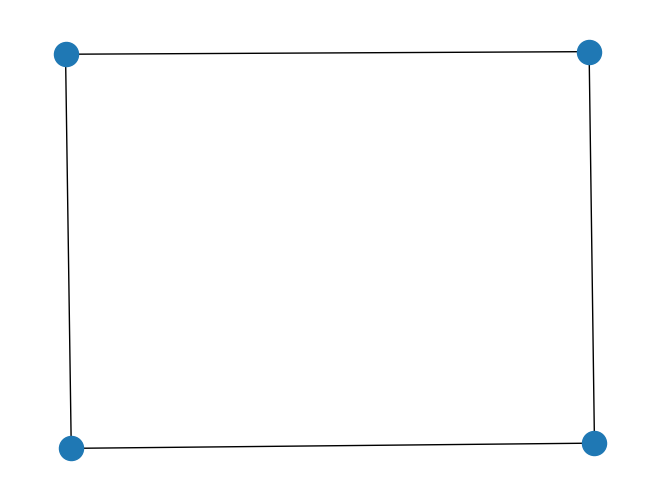

In [51]:
nx.draw(G_test2)

In [52]:
nx.betweenness_centrality(G_test2)

{'A': 0.16666666666666666,
 'B': 0.16666666666666666,
 'C': 0.16666666666666666,
 'D': 0.16666666666666666}

(c)

My original function differs from NetworkX for three main reasons. First, it initially counted self-paths such as A → A, which should not be included in betweenness centrality. Second, it normalized by the number of reachable paths rather than all possible source-destination pairs, which causes differences in disconnected graphs. Third, nx.shortest_path() returns only one shortest path, while standard betweenness must account for all equally short paths and divide the contribution among them.

(d)

In [53]:
def betweenness_centrality_from_scratch(G):

    # Error 1: input must be a NetworkX graph
    if not isinstance(G, (nx.Graph, nx.DiGraph, nx.MultiGraph, nx.MultiDiGraph)):
        return "Error: G must be a NetworkX graph object."

    # Error 2: graph must contain at least one node
    if G.number_of_nodes() == 0:
        return "Error: The graph contains no nodes."

    centrality = {}

    N = G.number_of_nodes()

    # If there are fewer than 3 nodes,
    # no node can be between two other nodes
    if N < 3:
        for node in G.nodes():
            centrality[node] = 0.0
        return centrality

    # Calculate betweenness for each target node
    for target_node in G.nodes():

        betweenness = 0.0

        # Consider every possible source node
        for source in G.nodes():

            # target_node cannot be the source
            if source == target_node:
                continue

            # Consider every possible destination node
            for destination in G.nodes():

                # source and destination must be different
                if source == destination:
                    continue

                # target_node cannot be the destination
                if destination == target_node:
                    continue

                try:
                    # Get ALL shortest paths between source and destination
                    paths = list(
                        nx.all_shortest_paths(
                            G,
                            source=source,
                            target=destination
                        )
                    )

                # If source and destination are disconnected,
                # this pair contributes 0
                except nx.NetworkXNoPath:
                    continue

                # Total number of shortest paths
                total_shortest_paths = len(paths)

                # Avoid possible division by zero
                if total_shortest_paths == 0:
                    continue

                # Count how many shortest paths contain target_node
                paths_through_target = 0

                for path in paths:

                    if target_node in path[1:-1]:
                        paths_through_target += 1

                # Contribution from this source-destination pair
                betweenness += (
                    paths_through_target /
                    total_shortest_paths
                )

        # Normalize
        denominator = (N - 1) * (N - 2)

        if denominator == 0:
            centrality[target_node] = 0.0
        else:
            centrality[target_node] = betweenness / denominator

    return centrality

In [54]:
def test_centrality(centrality_function):
    disconnected = nx.Graph()
    disconnected.add_edges_from([
        ("A", "B"), ("B", "C"), ("D", "E")
    ])

    tests = [
        ("not a graph", [1, 2, 3],
         "Error: G must be a NetworkX graph object."),
        ("no nodes", nx.Graph(),
         "Error: The graph contains no nodes."),
        ("one node", nx.empty_graph(1), {0: 0.0}),
        ("two nodes", nx.path_graph(2), {0: 0.0, 1: 0.0}),
        ("no edges", nx.empty_graph(4),
         {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0}),
        ("three-node path", nx.path_graph(3),
         {0: 0.0, 1: 1.0, 2: 0.0}),
        ("four-node cycle", nx.cycle_graph(4),
         {0: 1/6, 1: 1/6, 2: 1/6, 3: 1/6}),
        ("complete graph", nx.complete_graph(4),
         {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0}),
        ("disconnected", disconnected,
         {"A": 0.0, "B": 1/6, "C": 0.0, "D": 0.0, "E": 0.0}),
        ("directed path", nx.path_graph(3, create_using=nx.DiGraph()),
         {0: 0.0, 1: 0.5, 2: 0.0})
    ]

    passed_count = 0

    for name, graph, expected in tests:
        try:
            result = centrality_function(graph)

            if isinstance(expected, str):
                passed = isinstance(result, str) and result == expected
            else:
                passed = isinstance(result, dict)

                if passed:
                    passed = set(result) == set(expected)

                if passed:
                    for node in expected:
                        if not np.isclose(result[node], expected[node],
                                          rtol=1e-8, atol=1e-10):
                            passed = False
                            break

            print(name, "PASS" if passed else "FAIL")

            if passed:
                passed_count += 1
            else:
                print("  Expected:", expected)
                print("  Got:", result)

        except Exception as error:
            print(name, "FAIL:", error)

    print("Passed:", passed_count, "of", len(tests))


test_centrality(betweenness_centrality_from_scratch)

not a graph PASS
no nodes PASS
one node PASS
two nodes PASS
no edges PASS
three-node path PASS
four-node cycle PASS
complete graph PASS
disconnected PASS
directed path PASS
Passed: 10 of 10


I chose these tests to check error handling, division by zero, disconnected nodes, multiple shortest paths, and edge direction. Small graphs provide known values for comparison, and np.isclose allows small floating-point differences.

4.

(a)

In [55]:
import requests
from bs4 import BeautifulSoup

def get_course_prerequisites(dept_url):
    response = requests.get(dept_url, timeout=30)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    prerequisites = {}

    for course in soup.find_all("div", class_="courseblock"):

        title = course.find("p", class_="courseblocktitle")

        if title is None:
            continue

        course_code = title.get_text(strip=True).split(".")[0]
        course_code = " ".join(course_code.split())

        prereq_codes = []

        for extra in course.find_all(
            "p",
            class_="courseblockextra noindent"
        ):

            label = extra.find("strong")

            if label and label.get_text(strip=True).startswith("Prerequisite(s):"):

                for link in extra.find_all("a", class_="code", href=True):

                    code = " ".join(link.get_text().split())

                    if code not in prereq_codes:
                        prereq_codes.append(code)

        # Important:
        # include courses even if they have no prerequisites
        prerequisites[course_code] = prereq_codes

    return prerequisites

(b)

In [56]:
import time
from urllib.parse import urljoin

base_url = "https://catalog.northeastern.edu"
catalog_url = base_url + "/course-descriptions/"

response = requests.get(catalog_url)
response.raise_for_status()

soup = BeautifulSoup(response.text, "html.parser")

soup_alpha_div = soup.find("div", id="atozindex")

department_urls = {}

for ul in soup_alpha_div.find_all("ul"):
    for li in ul.find_all("li"):

        link = li.find("a", href=True)

        if link is None:
            continue

        href = link["href"]

        dept_code = href.rstrip("/").split("/")[-1].upper()

        department_urls[dept_code] = urljoin(base_url, href)

In [57]:
G_courses = nx.DiGraph()

department_data = {}

for dept, url in department_urls.items():

    print("Scraping:", dept)

    course_prereqs = get_course_prerequisites(url)

    department_data[dept] = course_prereqs

    for course, prereqs in course_prereqs.items():

        # Add the course as a node
        G_courses.add_node(course, department=dept)

        # prerequisite -> course
        for prereq in prereqs:
            G_courses.add_edge(prereq, course)

    # Be polite to the website
    time.sleep(1)

Scraping: ACCT
Scraping: ACC
Scraping: AVM
Scraping: AFCS
Scraping: AMSL
Scraping: ALY
Scraping: ANTH
Scraping: ANT
Scraping: AAI
Scraping: APL
Scraping: ARAB
Scraping: ARCH
Scraping: ARMY
Scraping: ART
Scraping: ARTG
Scraping: ARTF
Scraping: ARTE
Scraping: ARTH
Scraping: ARTD
Scraping: AACE
Scraping: ARTS
Scraping: ASNS
Scraping: BNSC
Scraping: BIOC
Scraping: BIOE
Scraping: BINF
Scraping: BIOL
Scraping: BIO
Scraping: BIOT
Scraping: BTC
Scraping: BUSN
Scraping: EXSC
Scraping: CHME
Scraping: CHEM
Scraping: CHM
Scraping: CHNS
Scraping: CIVE
Scraping: CED
Scraping: COMM
Scraping: CMN
Scraping: CMMN
Scraping: CNET
Scraping: CET
Scraping: CS
Scraping: CSYE
Scraping: CMG
Scraping: COOP
Scraping: COP
Scraping: EXED
Scraping: EEAM
Scraping: EEBA
Scraping: EESC
Scraping: EESH
Scraping: INNO
Scraping: CAEP
Scraping: CRTE
Scraping: CRWT
Scraping: CRIM
Scraping: CLTR
Scraping: CY
Scraping: DANC
Scraping: DADS
Scraping: DA
Scraping: DAMG
Scraping: DS
Scraping: DEAF
Scraping: DGM
Scraping: ENVR
Scra

In [58]:
print("Nodes:", G_courses.number_of_nodes())
print("Edges:", G_courses.number_of_edges())

Nodes: 7813
Edges: 5680


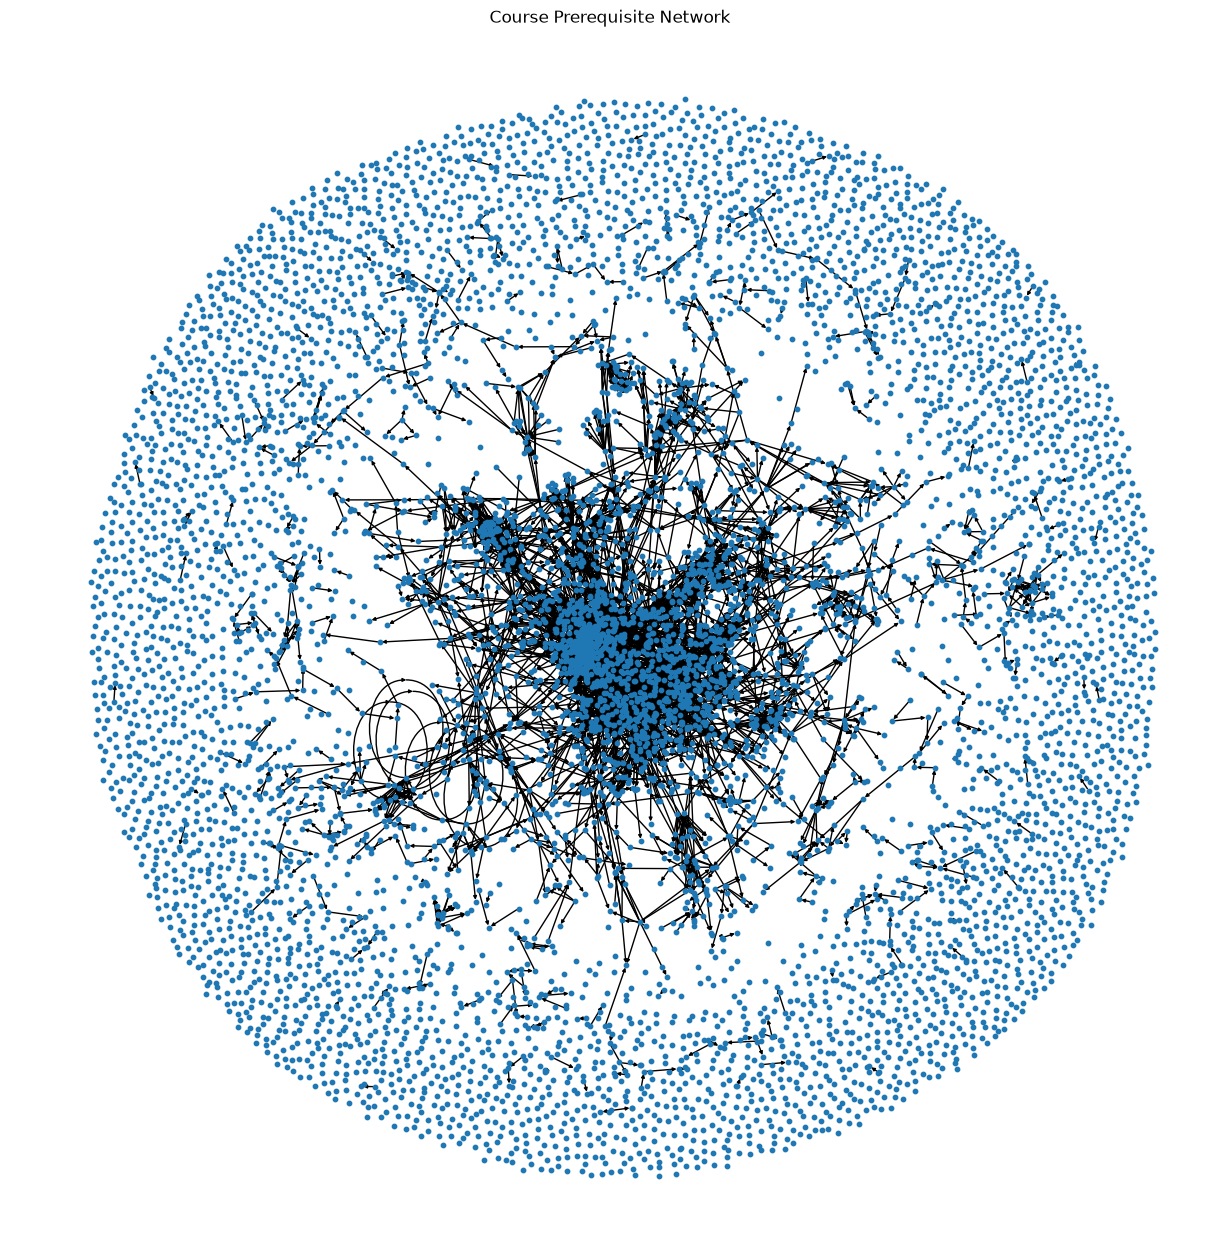

In [59]:
plt.figure(figsize=(12, 12))

nx.draw(
    G_courses,
    with_labels=False,
    node_size=10,
    arrows=True,
    arrowsize=5
)

plt.title("Course Prerequisite Network")
plt.show()

(c)

In [60]:
average_prereqs = {}

for dept, courses in department_data.items():

    n_courses = len(courses)

    if n_courses == 0:
        continue

    total_prereqs = sum(
        len(prereqs)
        for prereqs in courses.values()
    )

    average_prereqs[dept] = total_prereqs / n_courses

In [61]:
sorted(
    average_prereqs.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

[('ANTH', 2.6857142857142855),
 ('ORGB', 2.5),
 ('PSYC', 2.276595744680851),
 ('CRWT', 1.9583333333333333),
 ('LS', 1.8333333333333333),
 ('ENGL', 1.8272727272727274),
 ('BIOC', 1.7272727272727273),
 ('MUST', 1.7272727272727273),
 ('ECON', 1.6818181818181819),
 ('ENGW', 1.6666666666666667)]

Anthropology has the most prerequisites per course, on average, which surprises me, because I thought it would be the computer science or other STEM department

(d)

In [62]:
nx.is_directed_acyclic_graph(G_courses)

False

In [63]:
nx.find_cycle(G_courses)

[('EDU 7140', 'EDU 7150'), ('EDU 7150', 'EDU 7140')]

In [64]:
cycles = list(nx.simple_cycles(G_courses))

In [65]:
len(cycles)

8

In [66]:
cycles

[['SPNS 1101'],
 ['SPNS 1102'],
 ['SPNS 2101'],
 ['SPNS 2102'],
 ['SPNS 3101'],
 ['SPNS 3102'],
 ['SPNS 3602', 'SPNS 3603'],
 ['EDU 7140', 'EDU 7150']]

In [67]:
G_clean = G_courses.copy()
G_clean.remove_edges_from(nx.selfloop_edges(G_clean))

In [68]:
G_clean.remove_edge("SPNS 3603", "SPNS 3602")
G_clean.remove_edge("EDU 7150", "EDU 7140")

In [69]:
nx.is_directed_acyclic_graph(G_clean)

True

In [70]:
nx.dag_longest_path(G_clean)

['BIOL 1107',
 'BIOL 1113',
 'PHSC 2301',
 'PHSC 2303',
 'HSCI 1105',
 'NRSG 2220',
 'NRSG 3320',
 'NRSG 3420',
 'NRSG 4502',
 'NRSG 4610']

This doesn't change my answer to (c)，The ranking in (c) stays the same, but a high average may reflect alternative prerequisites, not more required courses.

One research question that could be answered with the prerequisite network is: Do departments with more courses in total tend to have more prerequisites per course on average?
For the co-occurrence network, one research question could be: Which concepts or topics tend to appear together most frequently across course descriptions?

5.

In [71]:
import networkx as nx
from scipy.io import mmread

In [72]:
A = mmread("socfb-Northeastern19.mtx")

G_fb = nx.from_scipy_sparse_array(A)

(a) 

This is a network about the Facebook friendship network of students at Northeastern University. 
Nodes are the students, and edges represent friendship ties.

The socfb-Northeastern19 dataset was obtained from Network Repository (Rossi & Ahmed, 2015). The original Facebook network study is described by Traud et al. (2012).

References

Traud, A. L., Mucha, P. J., & Porter, M. A. (2012). Social structure of Facebook networks. Physica A: Statistical Mechanics and its Applications, 391(16), 4165–4180. https://doi.org/10.1016/j.physa.2011.12.021

Rossi, R. A., & Ahmed, N. K. (2015). The Network Data Repository with Interactive Graph Analytics and Visualization. Proceedings of the AAAI Conference on Artificial Intelligence, 29(1). https://doi.org/10.1609/aaai.v29i1.9277

(b)

In [73]:
# Copy the original graph.
G_fb_random = G_fb.copy()

# Perform ten successful swaps per edge.
n_swaps = 10 * G_fb.number_of_edges()

nx.double_edge_swap(
    G_fb_random,
    nswap=n_swaps,
    max_tries=10 * n_swaps,
    seed=42
)

# Verify that every node retains its degree.
print("Original nodes:", G_fb.number_of_nodes())
print("Randomized nodes:", G_fb_random.number_of_nodes())

print("Original edges:", G_fb.number_of_edges())
print("Randomized edges:", G_fb_random.number_of_edges())

print("Every node's degree is preserved:",
      dict(G_fb.degree()) == dict(G_fb_random.degree()))

Original nodes: 13882
Randomized nodes: 13882
Original edges: 381934
Randomized edges: 381934
Every node's degree is preserved: True


In [ ]:
# 1. Eigenvector centrality
eigenvector = list(nx.eigenvector_centrality(
    G_fb, max_iter=2000, tol=1e-8, weight=None
).values())

In [ ]:
# 2. Average neighbor degree
neighbor_degree = list(nx.average_neighbor_degree(G_fb).values())

In [ ]:
# 3. Clustering coefficient
clustering = list(nx.clustering(G_fb, weight=None).values())

In [ ]:
# Eigenvector centrality
eigenvector_random = list(nx.eigenvector_centrality(
    G_fb_random, max_iter=2000, tol=1e-8, weight=None
).values())

In [ ]:
# 2. Average neighbor degree
neighbor_degree_random = list( nx.average_neighbor_degree(G_fb_random).values())

In [ ]:
# Clustering coefficient
clustering_random = list(
    nx.clustering(G_fb_random, weight=None).values()
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Use the same 40 bins for the original and randomized networks.
eigenvector_bins = np.linspace(
    0, max(max(eigenvector), max(eigenvector_random)), 41
)
neighbor_bins = np.linspace(
    0, max(max(neighbor_degree), max(neighbor_degree_random)), 41
)
clustering_bins = np.linspace(0, 1, 41)

# Export figures beside this notebook, in the figures folder.
figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)


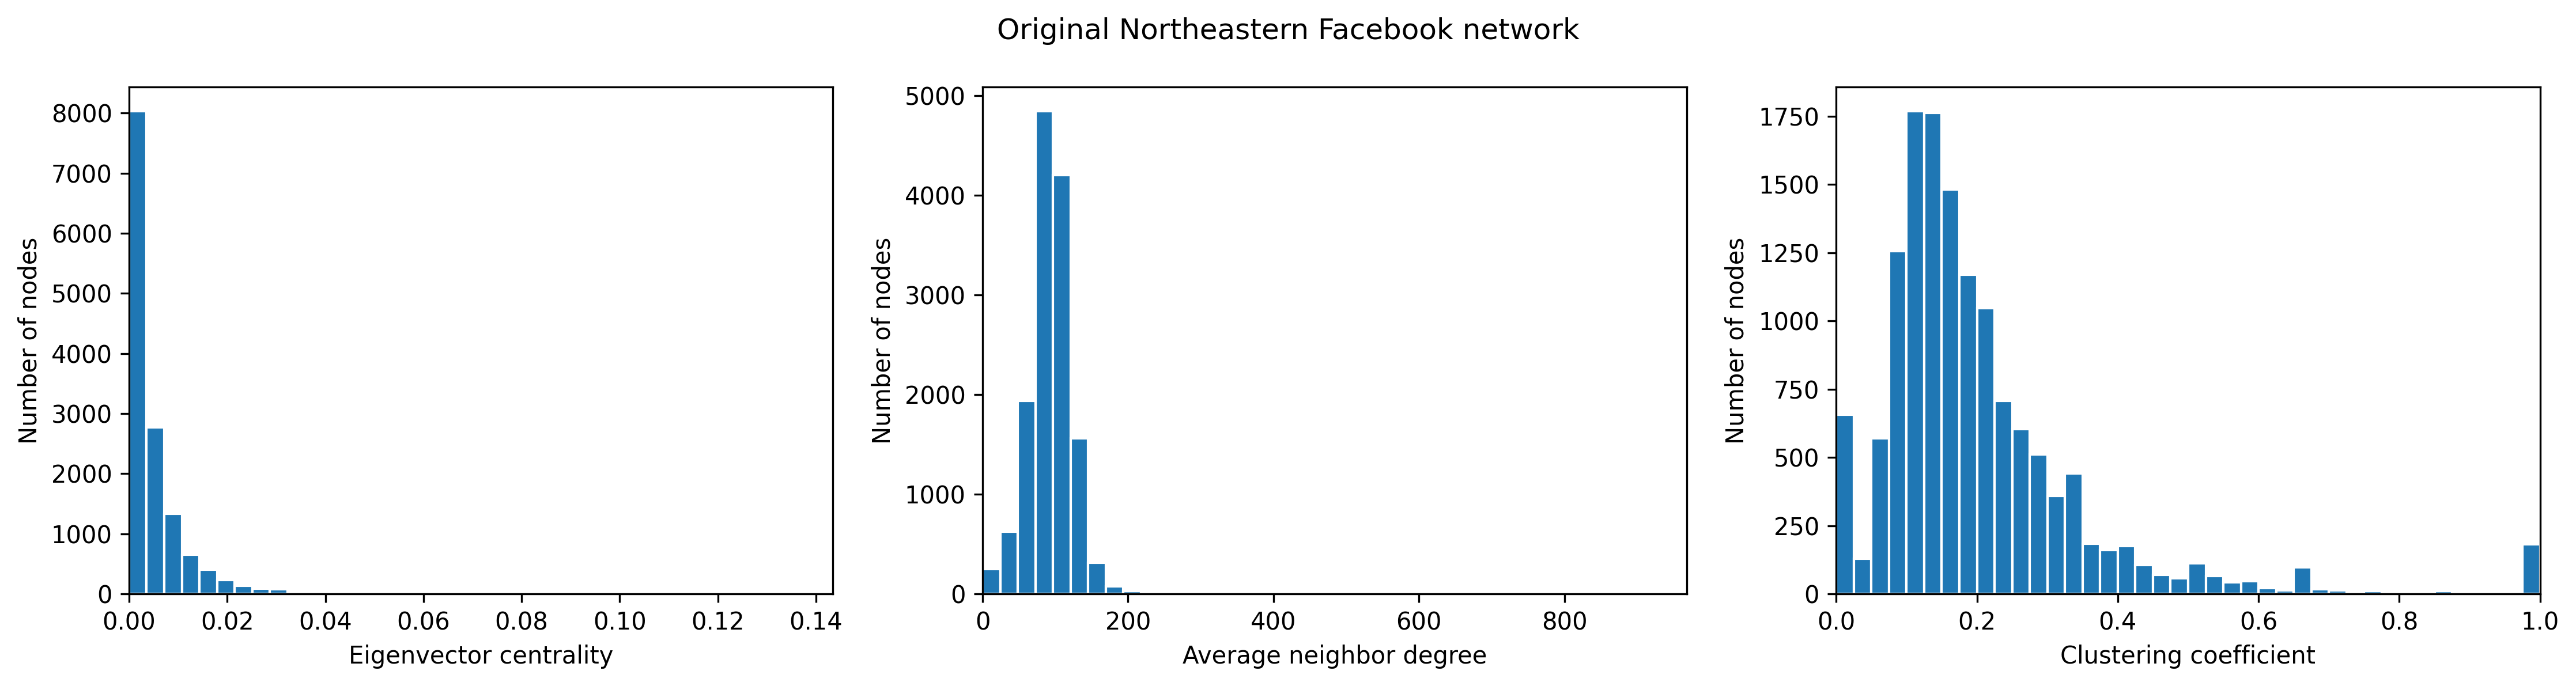

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(eigenvector, bins=eigenvector_bins, edgecolor="white")
axes[0].set_xlabel("Eigenvector centrality")

axes[1].hist(neighbor_degree, bins=neighbor_bins, edgecolor="white")
axes[1].set_xlabel("Average neighbor degree")

axes[2].hist(clustering, bins=clustering_bins, edgecolor="white")
axes[2].set_xlabel("Clustering coefficient")

for ax in axes:
    ax.set_ylabel("Number of nodes")

# Match the horizontal ranges in both figures.
axes[0].set_xlim(eigenvector_bins[0], eigenvector_bins[-1])
axes[1].set_xlim(neighbor_bins[0], neighbor_bins[-1])
axes[2].set_xlim(clustering_bins[0], clustering_bins[-1])

fig.suptitle("Original Northeastern Facebook network")
plt.tight_layout()
fig.savefig(figure_dir / "facebook_original.pdf", bbox_inches="tight")
fig.savefig(figure_dir / "facebook_original.png", dpi=300, bbox_inches="tight")
plt.show()

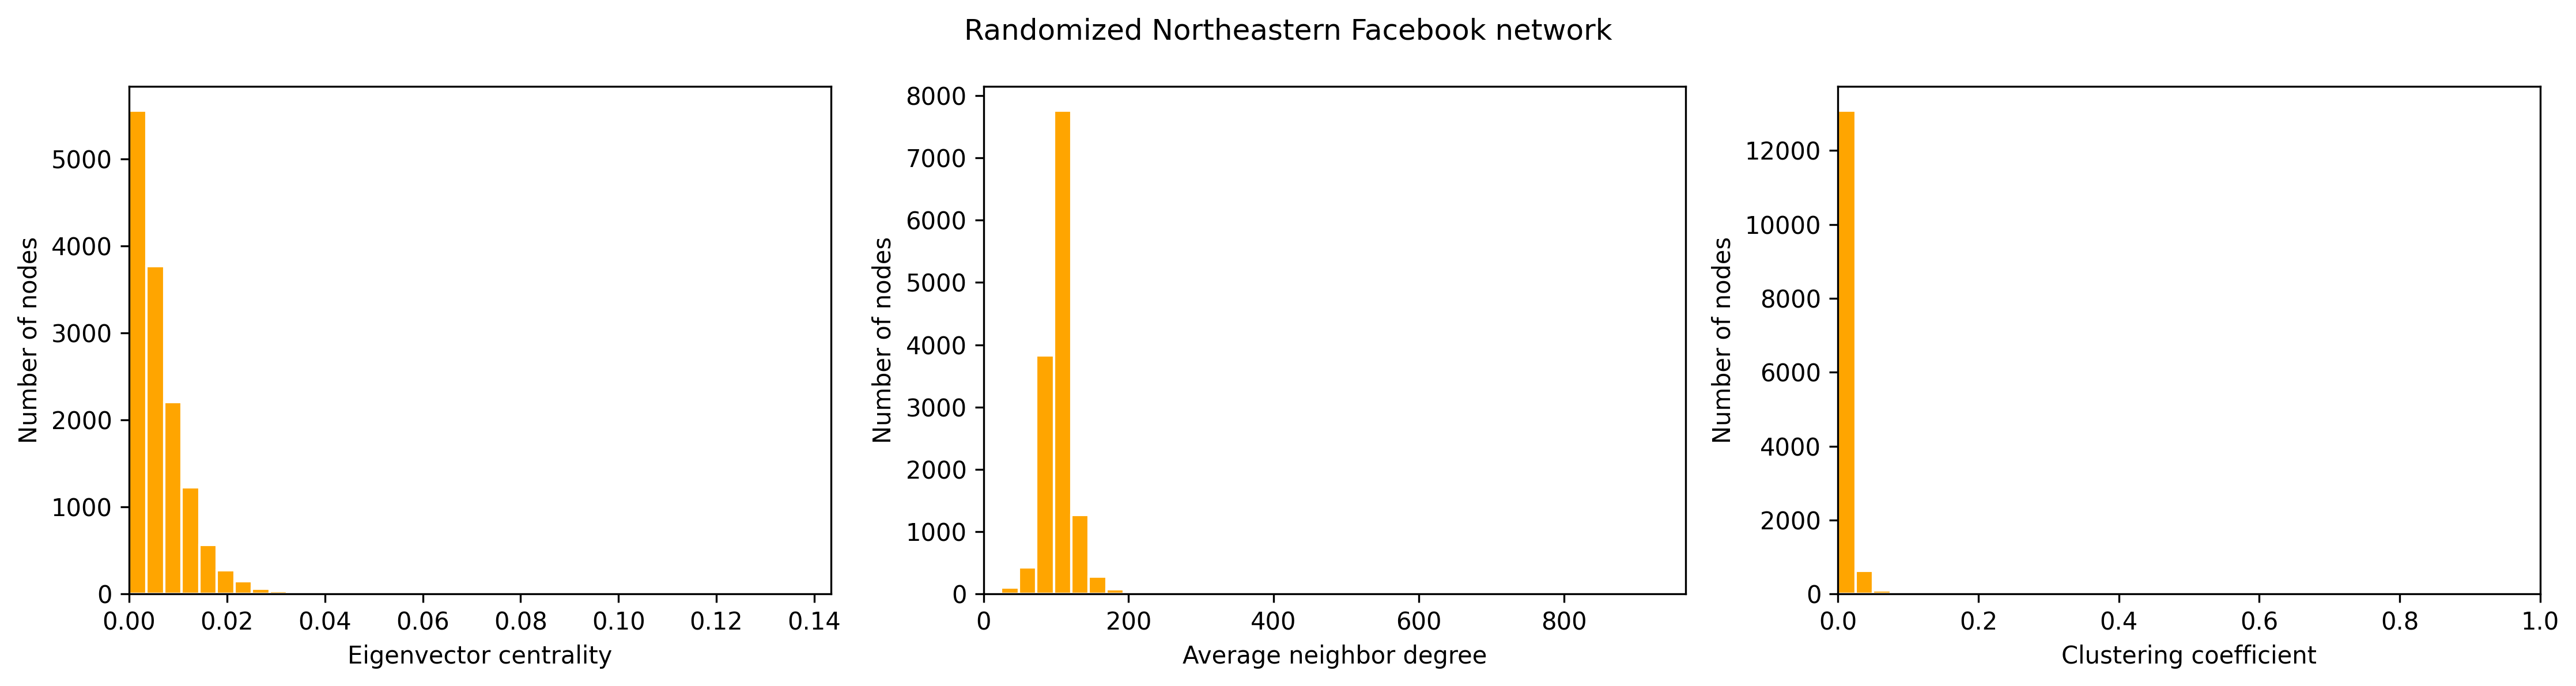

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(eigenvector_random, bins=eigenvector_bins,
    color="orange", edgecolor="white")
axes[0].set_xlabel("Eigenvector centrality")

axes[1].hist(neighbor_degree_random, bins=neighbor_bins,color="orange", edgecolor="white")
axes[1].set_xlabel("Average neighbor degree")

axes[2].hist(clustering_random, bins=clustering_bins,
    color="orange", edgecolor="white")
axes[2].set_xlabel("Clustering coefficient")

for ax in axes:
    ax.set_ylabel("Number of nodes")

# Match the horizontal ranges in both figures.
axes[0].set_xlim(eigenvector_bins[0], eigenvector_bins[-1])
axes[1].set_xlim(neighbor_bins[0], neighbor_bins[-1])
axes[2].set_xlim(clustering_bins[0], clustering_bins[-1])

fig.suptitle("Randomized Northeastern Facebook network")
plt.tight_layout()
fig.savefig(figure_dir / "facebook_random.pdf", bbox_inches="tight")
fig.savefig(figure_dir / "facebook_random.png", dpi=300, bbox_inches="tight")
plt.show()

(c) 

Eigenvector centrality: The randomized network still has a right-skewed eigenvector centrality distribution, although the shape changes after the original friendship structure is rewired.

Average neighbor degree: The randomized network shows a more concentrated distribution of average neighbor degree, because degree-preserving randomization removes many of the systematic patterns in who connects to whom.

Clustering coefficient: The largest difference is in clustering. Most clustering coefficients in the randomized network are close to zero, whereas the original network has much higher clustering.

   The original and randomized networks have the same degree distribution because the edge-swap procedure preserves every node's degree. However, their higher-order network structures are different. The clearest difference is the clustering coefficient: the original Facebook network has much higher clustering, while clustering in the randomized network is close to zero for most nodes. This suggests that the high level of clustering in the observed network cannot be explained by the degree distribution alone and instead reflects meaningful social structure, such as friendship groups. Comparing an observed network with a null model therefore helps us identify which network patterns are more structured than we would expect from degree alone.